In [2]:
from FNO2D_def import *  # your 2D FNO definition file
import h5py
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
import os
import matplotlib.pyplot as plt
import time

torch.manual_seed(0)
np.random.seed(0)

In [3]:
# Config

batch_size = 4  # reduce for 2D since fields are larger
lr = 2e-4
epochs = 500
val_patience = 25
res = 96

modes1 = modes2 = 8
width = 128

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")


# Paths
h5_path = path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N256_multi.h5"
h5_path = path = "/scratch/mnhagen/datasets/darcy_flow/darcy_beta1.h5"

dataset = "darcy"

In [4]:
# Dataset Definition

class DatasetLoader(torch.utils.data.Dataset):
    """
    Dataset for learning the direct mapping from 2-frame trajectories.
    """

    def __init__(self, h5_path, dataset, split="train", split_ratio=(0.8, 0.2), res = 128):
        super().__init__()
        self.dataset = dataset
        if self.dataset == "navierstokes":
            with h5py.File(h5_path, "r") as f:
                self.omega = f["omega"][:]   # (num_samples, 2, N, N)

        elif self.dataset == "darcy":
            with h5py.File(h5_path, "r") as f:
                nu = f["nu"][:]
                tensor = f["tensor"][:]

            tensor = tensor[:, 0, :, :]
            omega = np.stack([nu, tensor], axis = 1)
            self.omega = torch.from_numpy(omega)
        
        else:
            raise TypeError("This dataset is currently not supported by this loader. Pass either 'navierstokes' or 'darcy'.")
            

        self.num_samples = self.omega.shape[0]
        self.res = res
        n_train = int(self.num_samples * split_ratio[0])
        if split == "train":
            self.idxs = range(0, n_train)
        else:
            self.idxs = range(n_train, self.num_samples)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, idx):
        i = self.idxs[idx]

        # numpy -> torch
        ω_in  = torch.tensor(self.omega[i, 0, :, :], dtype=torch.float32)  # (H,W)
        ω_in = ω_in.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
        ω_in = F.interpolate(
            ω_in,
            size=(self.res, self.res),
            mode="bicubic",
            align_corners=False,
            antialias=True,          # optional but fine
        )
        ω_in = ω_in.squeeze(0)    # back to (1,H,W)


        ω_out = torch.tensor(self.omega[i, 1, :, :], dtype=torch.float32)  # (H,W)
        ω_out = ω_out.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
        ω_out = F.interpolate(
            ω_out,
            size=(self.res, self.res),
            mode="bicubic",
            align_corners=False,
            antialias=True,          # optional but fine
        )
        ω_out = ω_out.squeeze(0)    # back to (1,H,W)

        # add (C,H,W)

        # interpolate needs (N,C,H,W)
        

        return ω_in, ω_out


In [5]:
#Train model

train_ds = DatasetLoader(h5_path, dataset, split="train", res = res)
val_ds = DatasetLoader(h5_path, dataset, split="val", res = res)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

model = FNO2D(modes1, modes2, width)
model.q = torch.nn.Conv2d(width, 1, 1)
model.to(device)
best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_loss = 1e12
epochs_no_improve = 0
time_loss = np.zeros((2,epochs))

start_time = time.time()
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for ω_in, ω_target in train_loader:
        ω_in, ω_target = ω_in.to(device), ω_target.to(device)
        optimizer.zero_grad()

        ω_pred = model(ω_in.permute(0, 2, 3, 1))  # (B, H, W, 1)
        ω_pred = ω_pred.permute(0, 3, 1, 2)       # back to (B, 1, H, W)

        loss = F.mse_loss(ω_pred, ω_target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for ω_in, ω_target in val_loader:
            ω_in, ω_target = ω_in.to(device), ω_target.to(device)
            ω_pred = model(ω_in.permute(0, 2, 3, 1))
            ω_pred = ω_pred.permute(0, 3, 1, 2)
            val_loss += F.mse_loss(ω_pred, ω_target).item()
    val_loss /= len(val_loader)
    scheduler.step()

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4e} | Val: {val_loss:.4e}")

    # Early stopping
    if val_loss < best_val_loss * (1 - 1e-3):
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0

    else:
        if best_val_loss * (1 - 1e-3) < val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve += 1
        if epochs_no_improve >= val_patience:
            print("Early stop triggered.")
            break

    time_loss[0][epoch] = time.time() - start_time
    time_loss[1][epoch] = val_loss

time_loss = time_loss[:, :epoch]
model.load_state_dict(best_state)

print("Training complete. Best val loss:", best_val_loss)


/tmp/ipykernel_1754920/2315136892.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ω_in  = torch.tensor(self.omega[i, 0, :, :], dtype=torch.float32)  # (H,W)
/tmp/ipykernel_1754920/2315136892.py:55: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ω_out = torch.tensor(self.omega[i, 1, :, :], dtype=torch.float32)  # (H,W)


Epoch 000 | Train: 2.7821e-03 | Val: 8.8232e-04
Epoch 001 | Train: 9.7677e-04 | Val: 1.4005e-03
Epoch 002 | Train: 7.4220e-04 | Val: 5.5294e-04
Epoch 003 | Train: 6.2382e-04 | Val: 9.0188e-04
Epoch 004 | Train: 5.5221e-04 | Val: 4.4735e-04
Epoch 005 | Train: 4.9245e-04 | Val: 5.8229e-04
Epoch 006 | Train: 4.7104e-04 | Val: 4.5186e-04
Epoch 007 | Train: 4.5962e-04 | Val: 6.0415e-04
Epoch 008 | Train: 4.4079e-04 | Val: 4.3511e-04
Epoch 009 | Train: 3.9839e-04 | Val: 6.9588e-04
Epoch 010 | Train: 3.7968e-04 | Val: 5.9668e-04
Epoch 011 | Train: 3.3171e-04 | Val: 6.2051e-04
Epoch 012 | Train: 3.1848e-04 | Val: 4.8117e-04
Epoch 013 | Train: 2.9409e-04 | Val: 5.5344e-04
Epoch 014 | Train: 2.9414e-04 | Val: 5.2705e-04
Epoch 015 | Train: 2.7462e-04 | Val: 4.4059e-04
Epoch 016 | Train: 2.6260e-04 | Val: 4.9473e-04
Epoch 017 | Train: 2.3731e-04 | Val: 4.6648e-04
Epoch 018 | Train: 2.3611e-04 | Val: 4.6732e-04
Epoch 019 | Train: 2.0123e-04 | Val: 4.6380e-04
Epoch 020 | Train: 1.9058e-04 | Val: 4.5

In [6]:
#Save model

model_name = "FNO2D_darcy_flow_N96_k8"

model_dir = "/scratch/mnhagen/models/darcy_flow"
model_loss_name = model_name + "_loss"
model_path = os.path.join(model_dir, model_name + ".pt")
model_loss_path = os.path.join(model_dir, model_loss_name + ".csv")

model_dir = "/scratch/mnhagen/models/darcy_flow"
os.makedirs(model_dir, exist_ok=True)
save_path = os.path.join(model_dir, model_name + ".pt")

torch.save(model.state_dict(), save_path)
print(f"Model saved to {model_path}")

np.savetxt(
    model_loss_path,
    time_loss,
    delimiter=",",
    fmt="%.6f"   # controls number formatting
)
print(f"Model loss saved to {model_loss_path}")

Model saved to /scratch/mnhagen/models/darcy_flow/FNO2D_darcy_flow_N96_k8.pt
Model loss saved to /scratch/mnhagen/models/darcy_flow/FNO2D_darcy_flow_N96_k8_loss.csv


The code below is for plotting model predictions; either skip the load model cell to use the model just trained or load a model to test

In [ ]:
#Load model

load_path = "/scratch/mnhagen/models/heat2d/FNO2D_heat2d_multi128.pt"
h5_path = path = "/scratch/mnhagen/datasets/heat2d_multires/heat2D_autoreg_N256_multi.h5"

model = FNO2D(modes1, modes2, width)
model.q = torch.nn.Conv2d(width, 1, 1)  # one output channel (vorticity)
model.load_state_dict(torch.load(load_path, map_location=device))
model.to(device)
model.eval()

FNO2D(
  (p): Linear(in_features=3, out_features=128, bias=True)
  (conv0): SpectralConv2d()
  (conv1): SpectralConv2d()
  (conv2): SpectralConv2d()
  (conv3): SpectralConv2d()
  (mlp0): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (mlp1): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (mlp2): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (mlp3): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (w0): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (w1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (w3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1,

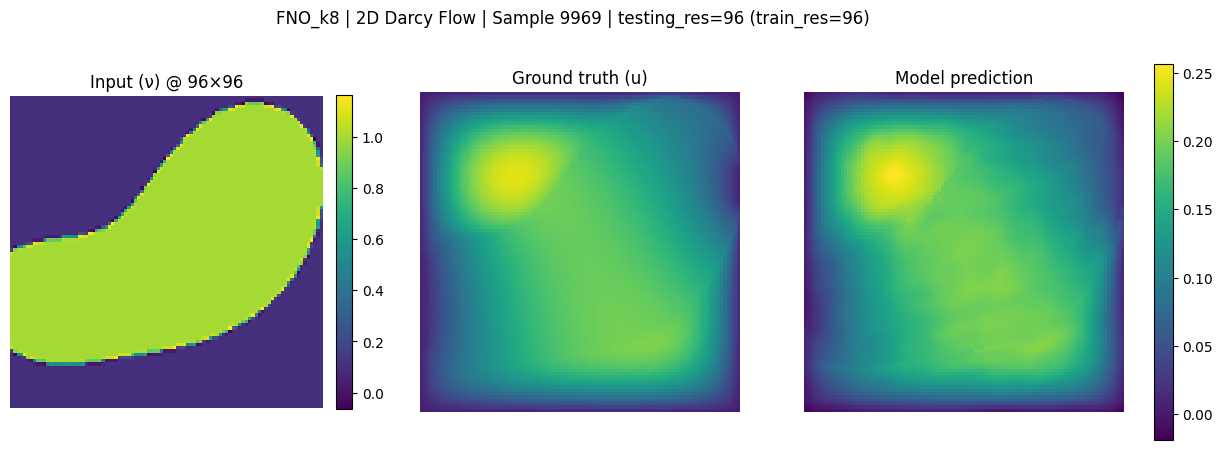

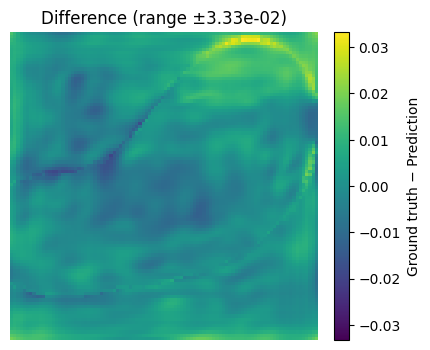

In [1]:
# Plot model prediction: Darcy flow (CNO) with configurable testing resolution
# - Full dataset is 128x128
# - Model trained on 96x96 (CNO.size = 96)
# - We first resample BOTH a (nu) and u (solution) to testing_res
# - Then run the model on the resampled a, and compare/plot on testing_res

import numpy as np
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from FNO2D_def import FNO2D  # adjust import if needed

# ------------------------------------------------------------------
# Paths and config
# ------------------------------------------------------------------
data_path = "/scratch/mnhagen/datasets/darcy_flow/darcy_beta1.h5"

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

sample_idx = 9969
width = 128

# Model training resolution (must match checkpoint)
train_res = 96

# >>> NEW: resolution you want to test/visualize on <<<
testing_res = 96   # e.g. 64, 80, 96, 112, 128, ...

# CNO architecture (must match training!)

# ------------------------------------------------------------------
# Helper: bicubic resample a 2D numpy array to (R,R)
# ------------------------------------------------------------------
def resample_2d_np(arr_2d: np.ndarray, R: int) -> np.ndarray:
    """Resample a (H,W) array to (R,R) using bicubic interpolation (PyTorch)."""
    t = torch.from_numpy(arr_2d).float().unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
    t_rs = F.interpolate(t, size=(R, R), mode="bicubic", align_corners=False)
    return t_rs[0, 0].numpy()

# ------------------------------------------------------------------
# Load model (trained on train_res)
# ------------------------------------------------------------------
FNO_k8_path = f"/scratch/mnhagen/models/darcy_flow/FNO2D_darcy_flow_N{train_res}_k8.pt"

FNO_k8 = FNO2D(8, 8, width)
FNO_k8.q = torch.nn.Conv2d(width, 1, 1)
FNO_k8.load_state_dict(torch.load(FNO_k8_path, map_location=device))
FNO_k8 = FNO_k8.to(device).eval()

# ------------------------------------------------------------------
# Load one sample (native dataset resolution, likely 128x128)
# ------------------------------------------------------------------
with h5py.File(data_path, "r") as f:
    a_native = np.squeeze(f["nu"][sample_idx])       # (128,128)
    u_native = np.squeeze(f["tensor"][sample_idx])   # (128,128) or (128,128,1) -> squeezed to (128,128)

# ------------------------------------------------------------------
# NEW: Resample BOTH a and u to testing_res BEFORE anything else
# ------------------------------------------------------------------
a = a_native if a_native.shape == (testing_res, testing_res) else resample_2d_np(a_native, testing_res)
u = u_native if u_native.shape == (testing_res, testing_res) else resample_2d_np(u_native, testing_res)

# ------------------------------------------------------------------
# Model inference on the resampled input a
# ------------------------------------------------------------------
ω_in = torch.from_numpy(a).float().unsqueeze(0).unsqueeze(0).to(device)  # (1,1,testing_res,testing_res)

with torch.no_grad():
    ω_pred = FNO_k8(ω_in).detach().cpu()

# Handle output layouts
if ω_pred.ndim == 4 and ω_pred.shape[1] == 1:   # (B,C,H,W)
    ω_pred_np = ω_pred[0, 0].numpy()
else:                                           # (B,H,W,C)
    ω_pred_np = ω_pred[0, :, :, 0].numpy()

# If the model output resolution differs from testing_res (e.g. model forces 96),
# resample prediction to testing_res so comparisons are on the requested grid.
if ω_pred_np.shape != (testing_res, testing_res):
    ω_pred_np = resample_2d_np(ω_pred_np, testing_res)

# ------------------------------------------------------------------
# Plot input, ground truth, prediction
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Input (independent scale)
im0 = axes[0].imshow(
    a,
    cmap="viridis",
    origin="lower",
    vmin=np.min(a),
    vmax=np.max(a),
)
axes[0].set_title(f"Input (ν) @ {testing_res}×{testing_res}")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Truth & prediction (shared scale)
common_min = min(np.min(u), np.min(ω_pred_np))
common_max = max(np.max(u), np.max(ω_pred_np))

im1 = axes[1].imshow(
    u,
    cmap="viridis",
    origin="lower",
    vmin=common_min,
    vmax=common_max,
)
axes[1].set_title("Ground truth (u)")
axes[1].axis("off")

im2 = axes[2].imshow(
    ω_pred_np,
    cmap="viridis",
    origin="lower",
    vmin=common_min,
    vmax=common_max,
)
axes[2].set_title("Model prediction")
axes[2].axis("off")

fig.colorbar(im1, ax=axes[1:], fraction=0.025, pad=0.04)

plt.suptitle(f"FNO_k8 | 2D Darcy Flow | Sample {sample_idx} | testing_res={testing_res} (train_res={train_res})")
plt.show()

# ------------------------------------------------------------------
# Difference plot: ground truth − prediction
# ------------------------------------------------------------------
diff = u - ω_pred_np
max_abs_diff = np.max(np.abs(diff))

plt.figure(figsize=(5, 4))
plt.imshow(
    diff,
    cmap="viridis",
    origin="lower",
    vmin=-max_abs_diff,
    vmax=max_abs_diff,
)
plt.colorbar(fraction=0.046, pad=0.04, label="Ground truth − Prediction")
plt.title(f"Difference (range ±{max_abs_diff:.2e})")
plt.axis("off")
plt.show()



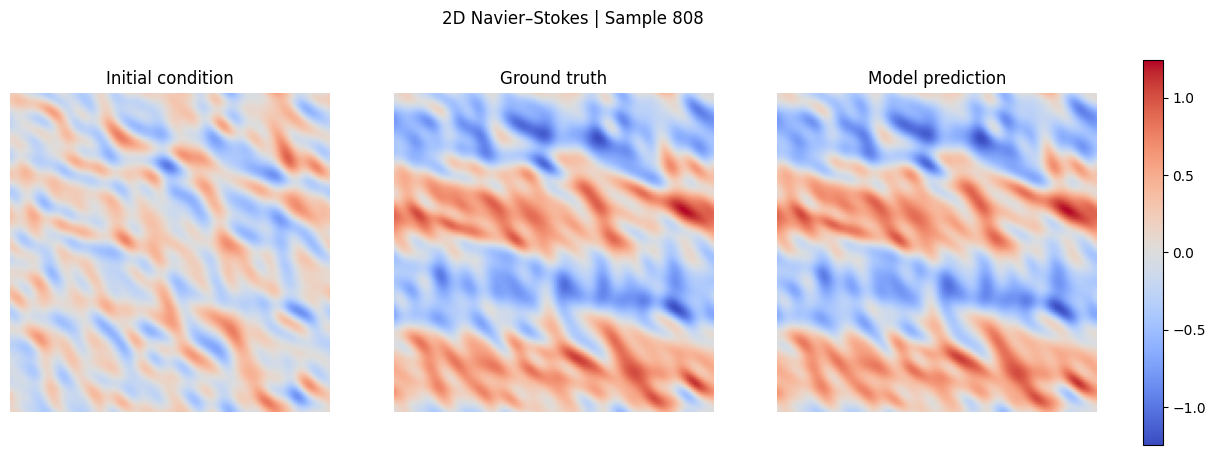

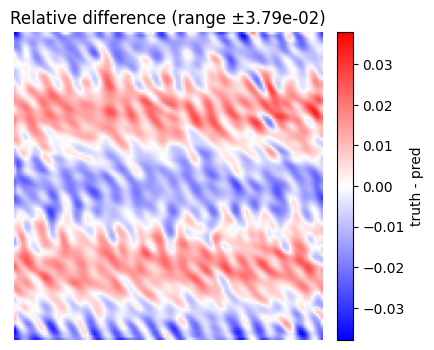

In [17]:
# Plot model prediction

sample_idx = 808
sub = 2

with h5py.File(h5_path, "r") as f:
    omega = f[dataset][:]  # (num_samples, 2, N, N)
omega0 = omega[sample_idx, 0, ::sub, ::sub]
omegaT = omega[sample_idx, 1, ::sub, ::sub]


ω_in = torch.tensor(omega0[None, None, :, :], dtype=torch.float32).to(device)  # (1,1,H,W)
with torch.no_grad():
    ω_pred = model(ω_in.permute(0, 2, 3, 1))  # -> (1,H,W,1)
ω_pred = ω_pred[0, ..., 0].cpu().numpy()  # (H,W)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Initial condition", "Ground truth", "Model prediction"]
fields = [omega0, omegaT, ω_pred]

vmin = min(np.min(f) for f in fields)
vmax = max(np.max(f) for f in fields)

for ax, field, title in zip(axes, fields, titles):
    im = ax.imshow(field, cmap="coolwarm", origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
plt.suptitle(f"2D Navier–Stokes | Sample {sample_idx}")
#plt.tight_layout()
plt.show()


diff = omegaT - ω_pred
max_abs_diff = np.max(np.abs(diff))

plt.figure(figsize=(5, 4))
plt.imshow(diff, cmap="bwr", origin="lower",
           vmin=-max_abs_diff, vmax=max_abs_diff)
plt.colorbar(fraction=0.046, pad=0.04, label="truth - pred")
plt.title(f"Relative difference (range ±{max_abs_diff:.2e})")
plt.axis("off")
plt.show()